# AI Image Forensics — Clean PyTorch Pipeline (v3)

This notebook keeps the complete analysis from the previous notebook, but simplifies the tensor shapes and keeps image processing in PyTorch whenever practical.

### Analyses
- FFT / Fourier frequency analysis
- 3-level Haar DWT
- 8×8 block DCT
- Gaussian high-pass residuals
- 2×2 cross-difference
- Synthbuster-inspired periodic FFT features
- Sobel gradient, Laplacian, Canny and contour analysis
- LBP texture analysis
- GLCM texture analysis
- Intensity, RGB, HSV and entropy analysis
- Error Level Analysis (ELA)
- Paired real-vs-AI feature differences
- Cohen's paired effect size
- Exact paired sign-flip test
- Benjamini–Hochberg FDR correction

The main design goal is simple: images are decoded directly into Torch tensors, transformed with TorchVision, and tensor-based analyses remain on the selected device until scalar features are needed. Kornia, `ptwt`, and `torch-dct` provide tensor-native computer-vision, wavelet, and DCT operations. Specialized CPU operations such as GLCM, contours, and statistical tests remain where they are appropriate.

### v3 scope

This version keeps the existing PyTorch/TorchVision/Kornia/ptwt pipeline and adds a color-quaternion wavelet analysis module. It remains a **feature-analysis notebook**, not a trained AI detector. The purpose is to understand which representations differ between matched real/AI pairs before moving to a larger official dataset.


In [1]:
# Install once in the SAME Python environment/kernel used by this notebook:
# %pip install -U torch torchvision kornia ptwt torch-dct numpy scipy scikit-image opencv-python pandas matplotlib

from pathlib import Path
import itertools
import math

import torch
import torch.nn.functional as F
from torchvision.io import decode_image, encode_jpeg, ImageReadMode
from torchvision.transforms import v2
import kornia
import kornia.filters as KF
import ptwt
import torch_dct as tdct
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from skimage.feature import graycomatrix, graycoprops

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ANALYSIS_SIZE = (512, 512)
OUT_DIR = Path("analysis_outputs_refined")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SHOW_ALL_VISUALS = False
SAVE_ALL_PAIR_FIGURES = True

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

print("PyTorch:", torch.__version__)
print("TorchVision:", __import__("torchvision").__version__)
print("Kornia:", kornia.__version__)
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.13.0+cu130
TorchVision: 0.28.0+cu130
Kornia: 0.8.3
Device: cuda
GPU: NVIDIA GeForce RTX 3050 A Laptop GPU


In [2]:
# -----------------------------
# Dataset discovery and pairing
# -----------------------------

REAL_DIR = Path("real")
AI_DIR = Path("ai")

def index_images(folder):
    folder = Path(folder)
    if not folder.exists():
        raise FileNotFoundError(f"Dataset folder not found: {folder.resolve()}")
    if not folder.is_dir():
        raise NotADirectoryError(folder)

    index = {}
    duplicates = []

    for path in sorted(folder.iterdir()):
        if path.is_file() and path.suffix.lower() in IMAGE_EXTS:
            stem = path.stem.lower()
            if stem in index:
                duplicates.append((stem, index[stem], path))
            else:
                index[stem] = path

    if duplicates:
        names = ", ".join(stem for stem, _, _ in duplicates)
        raise RuntimeError(f"Duplicate filename stems in {folder}: {names}")

    return index

def find_pairs(real_dir=REAL_DIR, ai_dir=AI_DIR):
    real = index_images(real_dir)
    ai = index_images(ai_dir)

    common = sorted(set(real) & set(ai))
    missing_ai = sorted(set(real) - set(ai))
    missing_real = sorted(set(ai) - set(real))

    if missing_ai:
        print("Missing AI counterparts:", missing_ai)
    if missing_real:
        print("Missing real counterparts:", missing_real)

    pairs = [(stem, real[stem], ai[stem]) for stem in common]
    print(f"Matched pairs: {len(pairs)}")
    return pairs

pairs = find_pairs()
if not pairs:
    raise RuntimeError("No matched pairs found. Check real/ and ai/ folders.")

Matched pairs: 8


In [3]:
# -----------------------------
# Tensor-native image loading
# -----------------------------
# TorchVision recommends tensor-based v2 transforms for performance.
# decode_image() also lets us apply EXIF orientation during decoding.

ANALYSIS_TRANSFORM = v2.Compose([
    v2.Resize(512, antialias=True),
    v2.CenterCrop(ANALYSIS_SIZE),
    v2.ToDtype(torch.float32, scale=True),
])

def load_rgb_tensor(path, device=DEVICE):
    image = decode_image(
        str(path),
        mode=ImageReadMode.RGB,
        apply_exif_orientation=True,
    )
    image = ANALYSIS_TRANSFORM(image)       # [C,H,W], float32, [0,1]
    return image.unsqueeze(0).to(device)     # [B,C,H,W]

def rgb_to_gray_tensor(rgb):
    return (
        0.299 * rgb[:, 0:1]
        + 0.587 * rgb[:, 1:2]
        + 0.114 * rgb[:, 2:3]
    )

def load_pair_tensors(real_path, ai_path):
    real_rgb = load_rgb_tensor(real_path)
    ai_rgb = load_rgb_tensor(ai_path)
    return (
        real_rgb,
        ai_rgb,
        rgb_to_gray_tensor(real_rgb),
        rgb_to_gray_tensor(ai_rgb),
    )

example = load_rgb_tensor(pairs[0][1])
print("Example tensor:", tuple(example.shape), example.dtype, example.device)

Example tensor: (1, 3, 512, 512) torch.float32 cuda:0


In [4]:
# -----------------------------
# Shared helpers
# -----------------------------

def scalar(value):
    return float(value.detach().cpu())

def scalar_only(features):
    return {
        key: value
        for key, value in features.items()
        if np.isscalar(value) and not isinstance(value, (str, bytes))
    }

def safe_entropy(x, bins=256):
    x = x.reshape(-1).float()
    lo = x.min()
    hi = x.max()

    if scalar((hi - lo).abs()) < 1e-12:
        return 0.0

    hist = torch.histc(
        x,
        bins=bins,
        min=float(lo),
        max=float(hi),
    )
    p = hist / (hist.sum() + 1e-12)
    p = p[p > 0]
    return scalar(-(p * torch.log2(p)).sum())

def tensor_entropy_uint8(x):
    hist = torch.bincount(
        x.reshape(-1).long(),
        minlength=256,
    ).float()
    p = hist / (hist.sum() + 1e-12)
    p = p[p > 0]
    return scalar(-(p * torch.log2(p)).sum())

def frequency_radius(h, w, device):
    fy = torch.fft.fftshift(torch.fft.fftfreq(h, device=device))
    fx = torch.fft.fftshift(torch.fft.fftfreq(w, device=device))
    yy, xx = torch.meshgrid(fy, fx, indexing="ij")
    return torch.sqrt(xx.square() + yy.square()) / math.sqrt(0.5**2 + 0.5**2)

In [5]:
# -----------------------------
# FFT / Fourier analysis
# -----------------------------

def fft_features(gray, radial_bins=160):
    # Remove DC from the spatial image before measuring spectral structure.
    x = gray - gray.mean(dim=(-2, -1), keepdim=True)

    spectrum = torch.fft.fft2(x, norm="ortho")
    shifted = torch.fft.fftshift(spectrum, dim=(-2, -1))

    magnitude = shifted.abs()
    power = magnitude.square()

    h, w = gray.shape[-2:]
    radius = frequency_radius(h, w, gray.device).view(1, 1, h, w)
    total = power.sum() + 1e-12

    bins = torch.linspace(0, 1, radial_bins + 1, device=gray.device)
    radial_power = []

    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (radius >= lo) & (radius < hi)
        radial_power.append((power * mask).sum() / total)

    return {
        "fft_logmag_map": torch.log1p(magnitude),
        "fft_phase_map": torch.angle(shifted),
        "fft_radial_power": torch.stack(radial_power),
        "fft_radial_r": (bins[:-1] + bins[1:]) / 2,
        "low_freq_ratio": scalar(power[radius < 0.20].sum() / total),
        "mid_freq_ratio": scalar(power[(radius >= 0.20) & (radius < 0.50)].sum() / total),
        "high_freq_ratio": scalar(power[radius >= 0.50].sum() / total),
        "spectral_centroid": scalar((radius * power).sum() / total),
    }

def plot_fft_pair(stem, real_gray, ai_gray, show=True):
    real = fft_features(real_gray)
    ai = fft_features(ai_gray)

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))

    for row, features, image, label in [
        (0, real, real_gray, "Real"),
        (1, ai, ai_gray, "AI"),
    ]:
        axes[row, 0].imshow(image[0, 0].cpu(), cmap="gray")
        axes[row, 0].set_title(f"{label} — grayscale")

        axes[row, 1].imshow(features["fft_logmag_map"][0, 0].cpu(), cmap="magma")
        axes[row, 1].set_title(f"{label} — FFT magnitude")

        axes[row, 2].imshow(
            features["fft_phase_map"][0, 0].cpu(),
            cmap="twilight",
            vmin=-np.pi,
            vmax=np.pi,
        )
        axes[row, 2].set_title(f"{label} — FFT phase")

    for ax in axes.ravel():
        ax.axis("off")

    plt.tight_layout()
    if SAVE_ALL_PAIR_FIGURES:
        fig.savefig(OUT_DIR / f"{stem}_fft_phase.png", dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.semilogy(
        real["fft_radial_r"].cpu(),
        real["fft_radial_power"].cpu() + 1e-14,
        label="Real",
    )
    ax.semilogy(
        ai["fft_radial_r"].cpu(),
        ai["fft_radial_power"].cpu() + 1e-14,
        label="AI",
    )
    ax.set_xlabel("Normalized radial frequency")
    ax.set_ylabel("Fraction of total power")
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()

    if SAVE_ALL_PAIR_FIGURES:
        fig.savefig(OUT_DIR / f"{stem}_fft_radial.png", dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)

    return real, ai

In [6]:
# -----------------------------
# DWT / Wavelet analysis
# -----------------------------

def dwt_features(gray, wavelet="haar", level=3):
    coeffs = ptwt.wavedec2(
        gray,
        wavelet,
        mode="symmetric",
        level=level,
    )

    approximation = coeffs[0]
    out = {
        f"LL{level}_energy": scalar(approximation.square().mean()),
        f"LL{level}_entropy": safe_entropy(approximation),
    }

    for index, details in enumerate(coeffs[1:], start=1):
        current_level = level - index + 1
        cH, cV, cD = details

        for name, band in zip(("LH", "HL", "HH"), (cH, cV, cD)):
            out[f"{name}{current_level}_energy"] = scalar(band.square().mean())
            out[f"{name}{current_level}_absmean"] = scalar(band.abs().mean())
            out[f"{name}{current_level}_entropy"] = safe_entropy(band)

    total_detail = sum(
        value for key, value in out.items()
        if "_energy" in key and not key.startswith("LL")
    )
    total_energy = sum(
        value for key, value in out.items()
        if key.endswith("_energy")
    )

    out["detail_energy_ratio"] = total_detail / (total_energy + 1e-12)
    return out, coeffs

def plot_dwt_pair(stem, real_gray, ai_gray, show=True):
    real, real_coeffs = dwt_features(real_gray)
    ai, ai_coeffs = dwt_features(ai_gray)

    fig, axes = plt.subplots(2, 4, figsize=(15, 7))

    for row, image, coeffs, label in [
        (0, real_gray, real_coeffs, "Real"),
        (1, ai_gray, ai_coeffs, "AI"),
    ]:
        axes[row, 0].imshow(image[0, 0].cpu(), cmap="gray")
        axes[row, 0].set_title(label)

        # Finest-scale detail tuple is the last tuple.
        for col, (band, name) in enumerate(
            zip(coeffs[-1], ("LH", "HL", "HH")),
            start=1,
        ):
            axes[row, col].imshow(band[0, 0].cpu(), cmap="gray")
            axes[row, col].set_title(f"{label} {name}")

    for ax in axes.ravel():
        ax.axis("off")

    plt.tight_layout()
    if SAVE_ALL_PAIR_FIGURES:
        fig.savefig(OUT_DIR / f"{stem}_dwt.png", dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)

    return real, ai


## Quaternion Wavelet / Color Quaternion Wavelet Analysis (v3)

This section adds a **color-aware quaternion wavelet analysis** motivated by the QWT/CQWT forensic literature.

The 2017 QWT paper reports that quaternion wavelet coefficients can be represented by **one magnitude and three phase angles**, and uses those quantities for photographic-vs-computer-generated image forensics. The 2019 CQWT paper specifically treats a color image as a unit and uses quaternion magnitude/phase plus quaternion skewness and kurtosis for CG-image identification. These papers establish the forensic motivation, but they do **not** provide a drop-in PyTorch implementation that we can reproduce exactly from the public material available to this notebook. citeturn3search0turn3search5

### What this notebook implements

For learning and exploratory analysis, we implement a **quaternion-valued Haar wavelet decomposition**:

1. Keep RGB together instead of converting to grayscale.
2. Apply the same Haar wavelet decomposition to the three color components.
3. Treat the corresponding R/G/B wavelet coefficients as a single **pure quaternion coefficient**
   \(q = 0 + R\,i + G\,j + B\,k\).
4. Compute quaternion magnitude and phase-related statistics.
5. Compute quaternion skewness/kurtosis-style statistics on the coefficient magnitude.
6. Compute simple **cross-channel phase coherence** measures as an explicit exploratory extension.

**Important:** this is a faithful quaternion-valued wavelet *learning implementation*, but it is **not claimed to be an exact reproduction of the 2017/2019 QWT/CQWT algorithm**. A true analytic QWT uses 2-D analytic/quaternion wavelets and has a more specific construction. The literature itself notes that there is no single universally agreed QWT definition. citeturn1search8turn1search10

That distinction is kept explicit so the notebook does not overclaim what was implemented.


In [7]:

# -----------------------------
# Quaternion-valued color wavelet analysis
# -----------------------------

def _qwavelet_haar_once(x):
    """
    One level of a separable 2-D Haar transform for a tensor [B,1,H,W].
    Returns LL, LH, HL, HH.

    This is intentionally implemented with tensor slicing so it remains
    GPU-friendly and easy to inspect.
    """
    # Even/odd samples in x and y.
    x00 = x[..., 0::2, 0::2]
    x01 = x[..., 0::2, 1::2]
    x10 = x[..., 1::2, 0::2]
    x11 = x[..., 1::2, 1::2]

    ll = (x00 + x01 + x10 + x11) * 0.5
    lh = (x00 - x01 + x10 - x11) * 0.5
    hl = (x00 + x01 - x10 - x11) * 0.5
    hh = (x00 - x01 - x10 + x11) * 0.5

    return ll, lh, hl, hh


def quaternion_magnitude(r, g, b, eps=1e-12):
    """Magnitude of q = 0 + r*i + g*j + b*k."""
    return torch.sqrt(
        r.square() + g.square() + b.square() + eps
    )


def quaternion_phase_proxies(r, g, b, eps=1e-12):
    """
    Three interpretable pairwise angular coordinates for the pure quaternion
    q = r*i + g*j + b*k.

    These are deliberately called phase *proxies*, not the three canonical
    Euler angles of a full analytic QWT coefficient.

    Each angle measures the orientation of one color pair in coefficient space.
    """
    rg = torch.atan2(g, r + eps)
    rb = torch.atan2(b, r + eps)
    gb = torch.atan2(b, g + eps)
    return rg, rb, gb


def circular_resultant(values, eps=1e-12):
    """
    Circular concentration in [0,1].
    1 = angles strongly aligned; 0 = dispersed.
    """
    return torch.sqrt(
        torch.cos(values).mean().square()
        + torch.sin(values).mean().square()
        + eps
    )


def quaternion_wavelet_features(rgb, levels=3):
    """
    Exploratory color-quaternion Haar wavelet features.

    Input:
        rgb: [B, 3, H, W], float32 in [0,1]

    Returns:
        scalar feature dictionary and visualization cache.
    """
    if rgb.shape[1] != 3:
        raise ValueError("Expected RGB tensor with 3 channels.")

    current = rgb
    out = {}
    maps = []

    for level in range(1, levels + 1):
        r = current[:, 0:1]
        g = current[:, 1:2]
        b = current[:, 2:3]

        r_ll, r_lh, r_hl, r_hh = _qwavelet_haar_once(r)
        g_ll, g_lh, g_hl, g_hh = _qwavelet_haar_once(g)
        b_ll, b_lh, b_hl, b_hh = _qwavelet_haar_once(b)

        subbands = {
            "LL": (r_ll, g_ll, b_ll),
            "LH": (r_lh, g_lh, b_lh),
            "HL": (r_hl, g_hl, b_hl),
            "HH": (r_hh, g_hh, b_hh),
        }

        level_maps = {}

        for band_name, (qr, qg, qb) in subbands.items():
            mag = quaternion_magnitude(qr, qg, qb)
            phi_rg, phi_rb, phi_gb = quaternion_phase_proxies(
                qr, qg, qb
            )

            prefix = f"qwt_{band_name}{level}"

            out[f"{prefix}_magnitude_mean"] = scalar(mag.mean())
            out[f"{prefix}_magnitude_std"] = scalar(mag.std())
            out[f"{prefix}_magnitude_energy"] = scalar(mag.square().mean())
            out[f"{prefix}_magnitude_entropy"] = safe_entropy(mag)

            out[f"{prefix}_phase_rg_circular_coherence"] = scalar(
                circular_resultant(phi_rg)
            )
            out[f"{prefix}_phase_rb_circular_coherence"] = scalar(
                circular_resultant(phi_rb)
            )
            out[f"{prefix}_phase_gb_circular_coherence"] = scalar(
                circular_resultant(phi_gb)
            )

            out[f"{prefix}_phase_rg_std"] = scalar(phi_rg.std())
            out[f"{prefix}_phase_rb_std"] = scalar(phi_rb.std())
            out[f"{prefix}_phase_gb_std"] = scalar(phi_gb.std())

            # Quaternion-statistics-inspired features.
            centered = mag - mag.mean()
            std = mag.std() + 1e-12

            skewness = (centered / std).pow(3).mean()
            kurtosis = (centered / std).pow(4).mean()

            out[f"{prefix}_quaternion_skewness"] = scalar(skewness)
            out[f"{prefix}_quaternion_kurtosis"] = scalar(kurtosis)

            level_maps[band_name] = {
                "magnitude": mag,
                "phase_rg": phi_rg,
                "phase_rb": phi_rb,
                "phase_gb": phi_gb,
            }

        maps.append(level_maps)

        # The LL subband becomes the input to the next level.
        current = torch.cat([r_ll, g_ll, b_ll], dim=1)

    # A compact multiscale summary makes the final report easier to read.
    detail_energy = sum(
        value
        for key, value in out.items()
        if "_magnitude_energy" in key
        and not "_LL" in key
    )
    all_energy = sum(
        value
        for key, value in out.items()
        if "_magnitude_energy" in key
    )
    out["qwt_detail_magnitude_energy_ratio"] = (
        detail_energy / (all_energy + 1e-12)
    )

    return out, maps


def plot_qwt_pair(stem, real_rgb, ai_rgb, show=True):
    """
    Visualize the finest-level quaternion magnitude and three
    phase-proxy maps for the HH subband.
    """
    real_features, real_maps = quaternion_wavelet_features(real_rgb)
    ai_features, ai_maps = quaternion_wavelet_features(ai_rgb)

    real_hh = real_maps[-1]["HH"]
    ai_hh = ai_maps[-1]["HH"]

    fig, axes = plt.subplots(2, 4, figsize=(15, 7))

    rows = [
        ("Real", real_hh),
        ("AI", ai_hh),
    ]

    for row, (label, data) in enumerate(rows):
        maps_to_show = [
            ("Magnitude", data["magnitude"]),
            ("RG phase", data["phase_rg"]),
            ("RB phase", data["phase_rb"]),
            ("GB phase", data["phase_gb"]),
        ]

        for col, (title, image) in enumerate(maps_to_show):
            axes[row, col].imshow(
                image[0, 0].detach().cpu(),
                cmap="magma" if col == 0 else "twilight",
            )
            axes[row, col].set_title(f"{label} — {title}")
            axes[row, col].axis("off")

    plt.tight_layout()

    if SAVE_ALL_PAIR_FIGURES:
        fig.savefig(
            OUT_DIR / f"{stem}_qwt.png",
            dpi=160,
            bbox_inches="tight",
        )

    if show:
        plt.show()

    plt.close(fig)
    return real_features, ai_features


# Quick sanity check on the first pair.
if pairs:
    demo_stem, demo_real_path, demo_ai_path = pairs[0]
    demo_real_rgb, demo_ai_rgb, _, _ = load_pair_tensors(
        demo_real_path,
        demo_ai_path,
    )

    demo_real_qwt, _ = quaternion_wavelet_features(demo_real_rgb)
    demo_ai_qwt, _ = quaternion_wavelet_features(demo_ai_rgb)

    print(f"Quaternion-wavelet features: {len(demo_real_qwt)}")
    print("Example features:")
    for key in list(demo_real_qwt)[:12]:
        print(f"  {key}: real={demo_real_qwt[key]:.6f}, "
              f"AI={demo_ai_qwt[key]:.6f}")


Quaternion-wavelet features: 145
Example features:
  qwt_LL1_magnitude_mean: real=1.489182, AI=1.489436
  qwt_LL1_magnitude_std: real=0.757942, AI=0.690731
  qwt_LL1_magnitude_energy: real=2.792130, AI=2.695521
  qwt_LL1_magnitude_entropy: real=7.727242, AI=7.241254
  qwt_LL1_phase_rg_circular_coherence: real=0.982918, AI=0.985936
  qwt_LL1_phase_rb_circular_coherence: real=0.960515, AI=0.970835
  qwt_LL1_phase_gb_circular_coherence: real=0.988198, AI=0.991815
  qwt_LL1_phase_rg_std: real=0.185528, AI=0.168157
  qwt_LL1_phase_rb_std: real=0.283010, AI=0.242759
  qwt_LL1_phase_gb_std: real=0.154084, AI=0.128225
  qwt_LL1_quaternion_skewness: real=-0.058461, AI=0.040880
  qwt_LL1_quaternion_kurtosis: real=1.824152, AI=2.148906


In [8]:
# -----------------------------
# 8×8 block DCT
# -----------------------------

def block_dct_features(gray, block=8):
    # gray: [B,1,H,W]
    if gray.ndim != 4 or gray.shape[1] != 1:
        raise ValueError(f"Expected grayscale tensor [B,1,H,W], got {tuple(gray.shape)}")

    b, _, h, w = gray.shape
    h = (h // block) * block
    w = (w // block) * block

    x = gray[:, 0, :h, :w]

    # [B,H,W] -> [B,Hb,Wb,block,block]
    patches = x.reshape(
        b,
        h // block,
        block,
        w // block,
        block,
    ).permute(0, 1, 3, 2, 4)

    # [B,Hb,Wb,block,block] -> [B*Hb*Wb,block,block]
    patches = patches.reshape(-1, block, block)

    # torch-dct applies the 2D DCT over the last two dimensions.
    coeff = tdct.dct_2d(patches, norm="ortho")
    energy = coeff.square()

    total_energy = energy.sum(dim=(-2, -1)) + 1e-12
    dc_ratio = energy[:, 0, 0] / total_energy

    yy, xx = torch.meshgrid(
        torch.arange(block, device=gray.device),
        torch.arange(block, device=gray.device),
        indexing="ij",
    )

    # Same simple high-frequency definition used by the previous notebook.
    high_frequency = (yy + xx) >= block
    high_frequency_energy = energy[:, high_frequency].sum(dim=1)
    high_frequency_ratio = high_frequency_energy / total_energy

    # Mean coefficient map across all 8×8 blocks.
    mean_abs_map = coeff.abs().mean(dim=0)

    # Reconstruct the block grid of total-energy ratios for optional inspection.
    block_ratio = dc_ratio.reshape(b, h // block, w // block)

    return {
        "dct_dc_ratio_mean": scalar(dc_ratio.mean()),
        "dct_highfreq_ratio_mean": scalar(high_frequency_ratio.mean()),
        "dct_coeff_abs_mean": scalar(coeff.abs().mean()),
        "dct_coeff_map": mean_abs_map,
        "dct_dc_ratio_map": block_ratio,
    }

def plot_dct_pair(stem, real_gray, ai_gray, show=True):
    real = block_dct_features(real_gray)
    ai = block_dct_features(ai_gray)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(torch.log1p(real["dct_coeff_map"]).cpu(), cmap="viridis")
    axes[0].set_title("Real — mean |8×8 DCT|")
    axes[1].imshow(torch.log1p(ai["dct_coeff_map"]).cpu(), cmap="viridis")
    axes[1].set_title("AI — mean |8×8 DCT|")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    if SAVE_ALL_PAIR_FIGURES:
        fig.savefig(OUT_DIR / f"{stem}_dct.png", dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)

    return real, ai

In [9]:
# -----------------------------
# Residuals and cross-difference
# -----------------------------

def cross_difference(image):
    # image: [B,C,H,W] -> [B,C,H-1,W-1]
    return (
        image[..., :-1, :-1]
        + image[..., 1:, 1:]
        - image[..., 1:, :-1]
        - image[..., :-1, 1:]
    ).abs()

def synthbuster_peak_features(rgb, periods=(2, 4, 8)):
    out = {}

    for channel, name in enumerate(("r", "g", "b")):
        channel_image = rgb[:, channel:channel + 1]
        residual = cross_difference(channel_image)

        h, w = residual.shape[-2:]
        spectrum = torch.fft.fftshift(
            torch.fft.fft2(residual, norm="ortho"),
            dim=(-2, -1),
        )
        magnitude = spectrum.abs()

        cy, cx = h // 2, w // 2

        for period in periods:
            ky = min(max(1, round(h / period)), h // 2)
            kx = min(max(1, round(w / period)), w // 2)

            directions = {
                "x": [(0, kx), (0, -kx)],
                "y": [(ky, 0), (-ky, 0)],
                "d": [
                    (ky, kx), (ky, -kx),
                    (-ky, kx), (-ky, -kx),
                ],
            }

            for direction, offsets in directions.items():
                values = [
                    magnitude[..., cy + dy, cx + dx]
                    for dy, dx in offsets
                    if 0 <= cy + dy < h and 0 <= cx + dx < w
                ]

                if values:
                    out[f"synth_{name}_p{period}_{direction}_mean"] = scalar(
                        torch.stack(values).mean()
                    )

        radius = frequency_radius(h, w, residual.device).view(1, 1, h, w)
        power = magnitude.square()
        out[f"synth_{name}_fft_highfreq_ratio"] = scalar(
            power[radius >= 0.50].sum() / (power.sum() + 1e-12)
        )

    return out

def residual_features(rgb, gray):
    # Kornia requires a positive odd kernel size.
    blurred = KF.gaussian_blur2d(
        gray,
        kernel_size=(5, 5),
        sigma=(1.0, 1.0),
    )
    highpass = gray - blurred

    crossdiff = cross_difference(rgb)
    crossdiff_gray = rgb_to_gray_tensor(crossdiff)

    centered = crossdiff_gray - crossdiff_gray.mean(dim=(-2, -1), keepdim=True)
    spectrum = torch.fft.fftshift(
        torch.fft.fft2(centered, norm="ortho"),
        dim=(-2, -1),
    )

    power = spectrum.abs().square()
    h, w = crossdiff_gray.shape[-2:]
    radius = frequency_radius(h, w, crossdiff_gray.device).view(1, 1, h, w)
    total = power.sum() + 1e-12

    out = {
        "hp_std": scalar(highpass.std()),
        "hp_absmean": scalar(highpass.abs().mean()),
        "hp_kurtosis": float(
            stats.kurtosis(
                highpass.detach().cpu().numpy().ravel(),
                fisher=True,
                bias=False,
            )
        ),
        "crossdiff_std": scalar(crossdiff_gray.std()),
        "crossdiff_absmean": scalar(crossdiff_gray.abs().mean()),
        "crossdiff_fft_highfreq_ratio": scalar(
            power[radius >= 0.50].sum() / total
        ),
        "hp_map": highpass,
        "crossdiff_map": crossdiff_gray,
        "crossdiff_fft": torch.log1p(spectrum.abs()),
    }

    out.update(synthbuster_peak_features(rgb))
    return out

def plot_residual_pair(stem, real_rgb, ai_rgb, real_gray, ai_gray, show=True):
    real = residual_features(real_rgb, real_gray)
    ai = residual_features(ai_rgb, ai_gray)

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))

    for row, features, label in [
        (0, real, "Real"),
        (1, ai, "AI"),
    ]:
        for col, key, title in [
            (0, "hp_map", "Gaussian residual"),
            (1, "crossdiff_map", "Cross-difference"),
            (2, "crossdiff_fft", "Cross-difference FFT"),
        ]:
            axes[row, col].imshow(
                features[key][0, 0].cpu(),
                cmap="magma" if col == 2 else "gray",
            )
            axes[row, col].set_title(f"{label} — {title}")
            axes[row, col].axis("off")

    plt.tight_layout()
    if SAVE_ALL_PAIR_FIGURES:
        fig.savefig(OUT_DIR / f"{stem}_residuals.png", dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)

    return real, ai

In [10]:
# -----------------------------
# Edge, gradient, Laplacian, Canny, contours
# -----------------------------

def edge_contour_features(gray):
    gradient = KF.sobel(gray).abs()
    laplacian = KF.laplacian(gray, 3).abs()

    _, edges = KF.canny(
        gray,
        low_threshold=50 / 255,
        high_threshold=150 / 255,
    )

    edge_u8 = (edges[0, 0].detach().cpu().numpy() > 0).astype(np.uint8) * 255
    contours, _ = cv2.findContours(
        edge_u8,
        cv2.RETR_LIST,
        cv2.CHAIN_APPROX_SIMPLE,
    )

    perimeter = sum(
        cv2.arcLength(contour, closed=True)
        for contour in contours
    )

    return {
        "gradient_mean": scalar(gradient.mean()),
        "gradient_std": scalar(gradient.std()),
        "gradient_p95": scalar(torch.quantile(gradient.flatten(), 0.95)),
        "laplacian_absmean": scalar(laplacian.mean()),
        "laplacian_std": scalar(laplacian.std()),
        "edge_density": scalar(edges.mean()),
        "contour_count": len(contours),
        "contour_perimeter_per_area": perimeter / gray[0, 0].numel(),
        "gradient_map": gradient,
        "laplacian_map": laplacian,
        "edge_map": edges,
    }

def plot_edges_pair(stem, real_gray, ai_gray, show=True):
    real = edge_contour_features(real_gray)
    ai = edge_contour_features(ai_gray)

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))

    for row, features, label in [
        (0, real, "Real"),
        (1, ai, "AI"),
    ]:
        for col, key, title in [
            (0, "gradient_map", "Gradient magnitude"),
            (1, "laplacian_map", "|Laplacian|"),
            (2, "edge_map", "Canny edges"),
        ]:
            axes[row, col].imshow(
                features[key][0, 0].cpu(),
                cmap="magma" if col < 2 else "gray",
            )
            axes[row, col].set_title(f"{label} — {title}")
            axes[row, col].axis("off")

    plt.tight_layout()
    if SAVE_ALL_PAIR_FIGURES:
        fig.savefig(OUT_DIR / f"{stem}_edges_contours.png", dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)

    return real, ai

In [11]:
# -----------------------------
# LBP texture analysis
# -----------------------------

def lbp_features(gray, P=8, R=1):
    if P != 8 or R != 1:
        raise ValueError("This simple tensor implementation currently supports P=8, R=1.")

    x = (gray * 255).clamp(0, 255).float()
    padded = F.pad(x, (1, 1, 1, 1), mode="replicate")[0, 0]
    center = padded[1:-1, 1:-1]

    shifts = [
        (-1, -1), (-1, 0), (-1, 1), (0, 1),
        (1, 1), (1, 0), (1, -1), (0, -1),
    ]

    raw = torch.zeros_like(center, dtype=torch.int32)

    for bit, (dy, dx) in enumerate(shifts):
        neighbour = padded[
            1 + dy : 1 + dy + center.shape[0],
            1 + dx : 1 + dx + center.shape[1],
        ]
        raw += (neighbour >= center).to(torch.int32) * (1 << bit)

    bit_values = (
        (raw.unsqueeze(0) >> torch.arange(
            P, device=gray.device
        ).view(P, 1, 1)) & 1
    )

    transitions = (
        bit_values != torch.roll(bit_values, shifts=-1, dims=0)
    ).sum(dim=0)

    # Uniform LBP: <= 2 circular bit transitions.
    uniform = torch.where(
        transitions <= 2,
        bit_values.sum(dim=0),
        torch.full_like(
            transitions,
            P + 1,
            dtype=torch.int64,
        ),
    )

    hist = torch.bincount(
        uniform.flatten().long(),
        minlength=P + 2,
    ).float()
    hist /= hist.sum() + 1e-12

    entropy = -(hist[hist > 0] * torch.log2(hist[hist > 0])).sum()

    return {
        "lbp_hist_entropy": scalar(entropy),
        "lbp_dominant_bin": scalar(hist.max()),
        "lbp_mean_code": scalar(uniform.float().mean()),
        "lbp_std_code": scalar(uniform.float().std()),
        "lbp_map": uniform,
        "lbp_hist": hist,
    }

def plot_lbp_pair(stem, real_gray, ai_gray, show=True):
    real = lbp_features(real_gray)
    ai = lbp_features(ai_gray)

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    axes[0, 0].imshow(real["lbp_map"].cpu(), cmap="viridis")
    axes[0, 0].set_title("Real — LBP")

    axes[1, 0].imshow(ai["lbp_map"].cpu(), cmap="viridis")
    axes[1, 0].set_title("AI — LBP")

    axes[0, 1].plot(real["lbp_hist"].cpu(), marker="o", label="Real")
    axes[0, 1].plot(ai["lbp_hist"].cpu(), marker="o", label="AI")
    axes[0, 1].legend()

    x = np.arange(len(real["lbp_hist"]))
    axes[1, 1].bar(x - 0.18, real["lbp_hist"].cpu(), 0.36, label="Real")
    axes[1, 1].bar(x + 0.18, ai["lbp_hist"].cpu(), 0.36, label="AI")
    axes[1, 1].legend()

    plt.tight_layout()
    if SAVE_ALL_PAIR_FIGURES:
        fig.savefig(OUT_DIR / f"{stem}_lbp.png", dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)

    return real, ai

In [12]:
# -----------------------------
# GLCM texture analysis
# -----------------------------
# GLCM stays on CPU because scikit-image provides a mature implementation
# and this dataset is small. The image remains a tensor until quantization.

def glcm_features(gray, levels=32):
    quantized = torch.floor(
        gray.clamp(0, 1) * levels
    ).to(torch.uint8)

    quantized = quantized.clamp_max(levels - 1)
    image = quantized.squeeze().detach().cpu().numpy()

    distances = [1, 2, 4]
    angles = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]

    glcm = graycomatrix(
        image,
        distances=distances,
        angles=angles,
        levels=levels,
        symmetric=True,
        normed=True,
    )

    out = {}

    for property_name in [
        "contrast",
        "dissimilarity",
        "homogeneity",
        "ASM",
        "energy",
        "correlation",
    ]:
        values = graycoprops(glcm, property_name)
        out[f"glcm_{property_name}_mean"] = float(values.mean())
        out[f"glcm_{property_name}_std"] = float(values.std())

    entropy = -np.sum(
        glcm * np.log2(glcm + 1e-12),
        axis=(0, 1),
    )

    out["glcm_entropy_mean"] = float(entropy.mean())
    out["glcm_entropy_std"] = float(entropy.std())

    return out, glcm

In [13]:
# -----------------------------
# Intensity, colour, HSV, entropy
# -----------------------------

def intensity_color_features(rgb, gray):
    out = {
        "intensity_mean": scalar(gray.mean()),
        "intensity_std": scalar(gray.std()),
        "intensity_p01": scalar(torch.quantile(gray.flatten(), 0.01)),
        "intensity_p50": scalar(torch.quantile(gray.flatten(), 0.50)),
        "intensity_p99": scalar(torch.quantile(gray.flatten(), 0.99)),
        "intensity_entropy": tensor_entropy_uint8(
            (gray * 255).clamp(0, 255).to(torch.uint8)
        ),
    }

    for index, name in enumerate(("r", "g", "b")):
        channel = rgb[:, index:index + 1]
        out[f"{name}_mean"] = scalar(channel.mean())
        out[f"{name}_std"] = scalar(channel.std())
        out[f"{name}_entropy"] = tensor_entropy_uint8(
            (channel * 255).clamp(0, 255).to(torch.uint8)
        )

    flat = rgb[0].permute(1, 2, 0).reshape(-1, 3).detach().cpu().numpy()
    correlation = np.corrcoef(flat.T)

    out["rgb_corr_rg"] = float(correlation[0, 1])
    out["rgb_corr_rb"] = float(correlation[0, 2])
    out["rgb_corr_gb"] = float(correlation[1, 2])

    hsv = kornia.color.rgb_to_hsv(rgb)

    out["hsv_saturation_mean"] = scalar(hsv[:, 1].mean())
    out["hsv_value_mean"] = scalar(hsv[:, 2].mean())
    out["hsv_saturation_std"] = scalar(hsv[:, 1].std())

    return out

def plot_intensity_pair(stem, real_rgb, ai_rgb, real_gray, ai_gray, show=True):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(
        real_gray.flatten().cpu(),
        bins=64,
        density=True,
        alpha=0.6,
        label="Real",
    )
    axes[0].hist(
        ai_gray.flatten().cpu(),
        bins=64,
        density=True,
        alpha=0.6,
        label="AI",
    )
    axes[0].legend()
    axes[0].set_title("Grayscale intensity")

    for index, name in enumerate(("R", "G", "B")):
        axes[1].hist(
            real_rgb[0, index].flatten().cpu(),
            bins=64,
            density=True,
            alpha=0.4,
            label=f"Real {name}",
        )
        axes[1].hist(
            ai_rgb[0, index].flatten().cpu(),
            bins=64,
            density=True,
            histtype="step",
            linewidth=1.5,
            label=f"AI {name}",
        )

    axes[1].legend(ncol=2, fontsize=8)
    axes[1].set_title("RGB distributions")

    plt.tight_layout()
    if SAVE_ALL_PAIR_FIGURES:
        fig.savefig(OUT_DIR / f"{stem}_intensity_color.png", dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)

In [14]:
# -----------------------------
# Error Level Analysis
# -----------------------------
# ELA intentionally operates on the original file before our 512x512 analysis
# resize, so JPEG recompression is being compared against the original file.

def ela_features_from_path(path, quality=90, map_size=ANALYSIS_SIZE):
    original = decode_image(
        str(path),
        mode=ImageReadMode.RGB,
        apply_exif_orientation=True,
    ).to(torch.uint8)

    recompressed = encode_jpeg(original, quality=quality)
    reconstructed = decode_image(
        recompressed,
        mode=ImageReadMode.RGB,
    )

    difference = (
        original.float() - reconstructed.float()
    ).abs().mean(dim=0)

    ela_map = F.interpolate(
        difference[None, None],
        size=map_size,
        mode="bilinear",
        align_corners=False,
    )[0, 0] / 255.0

    return {
        "ela_mean": scalar(difference.mean() / 255),
        "ela_std": scalar(difference.std() / 255),
        "ela_p95": scalar(torch.quantile(difference.flatten(), 0.95) / 255),
        "ela_max": scalar(difference.max() / 255),
        "ela_map": ela_map,
    }

def plot_ela_pair(stem, real, ai, show=True):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    vmax = max(
        real["ela_map"].max().item(),
        ai["ela_map"].max().item(),
    ) + 1e-12

    axes[0].imshow(real["ela_map"].cpu(), cmap="inferno", vmin=0, vmax=vmax)
    axes[0].set_title("Real — ELA")

    axes[1].imshow(ai["ela_map"].cpu(), cmap="inferno", vmin=0, vmax=vmax)
    axes[1].set_title("AI — ELA")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    if SAVE_ALL_PAIR_FIGURES:
        fig.savefig(OUT_DIR / f"{stem}_ela.png", dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)

    return real, ai

## Feature extraction

Each real image is compared only with its corresponding AI image. Tensor-based image operations run under inference mode because the analysis does not require gradients.

The final feature table contains only scalar measurements. Large intermediate maps are kept out of the CSV files.

### v3 addition: quaternion color-wavelet features

The new `qwt_*` features are extracted from RGB before grayscale conversion. They are therefore complementary to the existing grayscale DWT. The statistical tests below treat them exactly like the other features; no classifier is trained in this notebook.


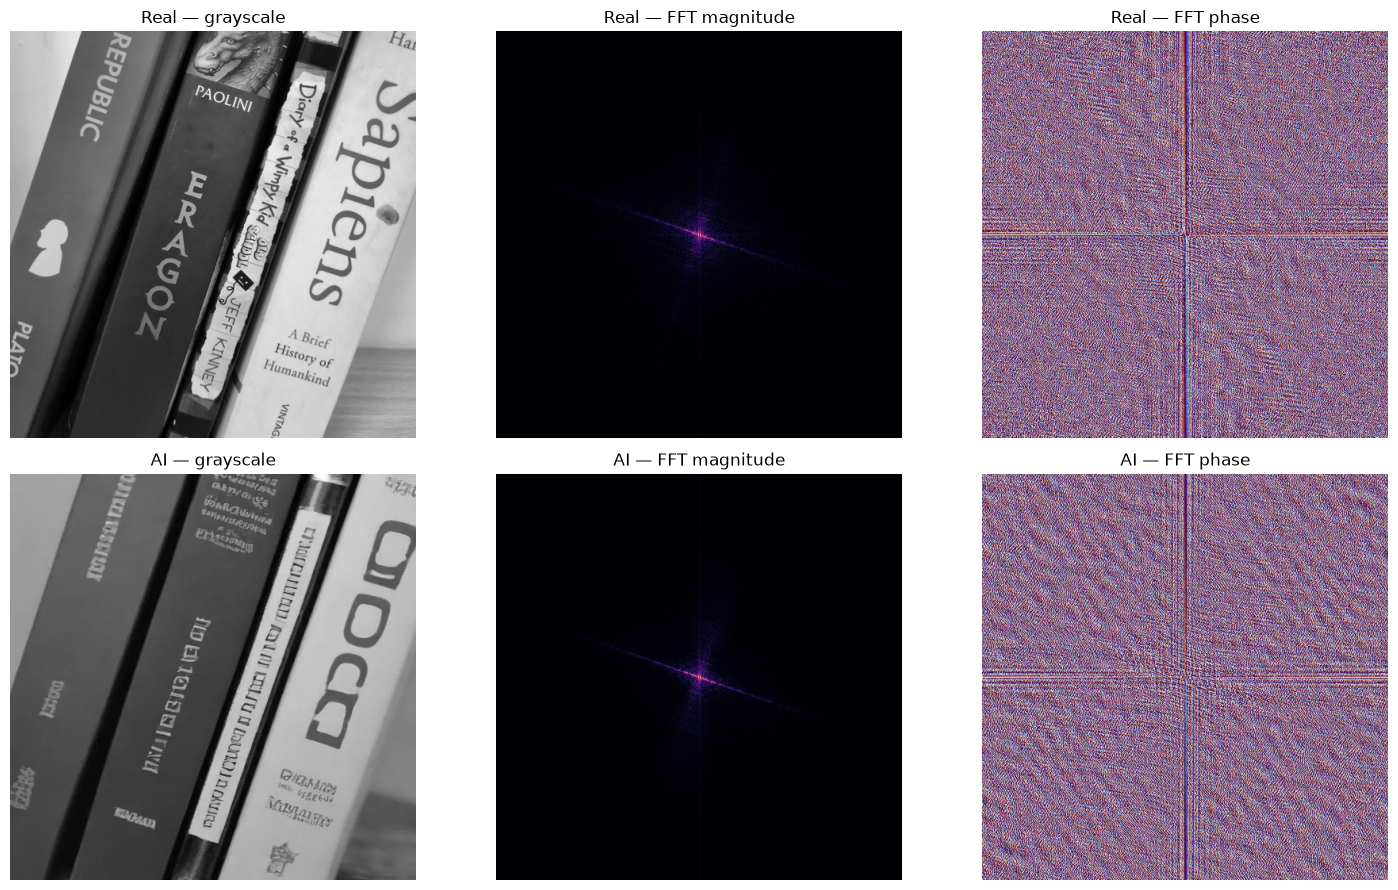

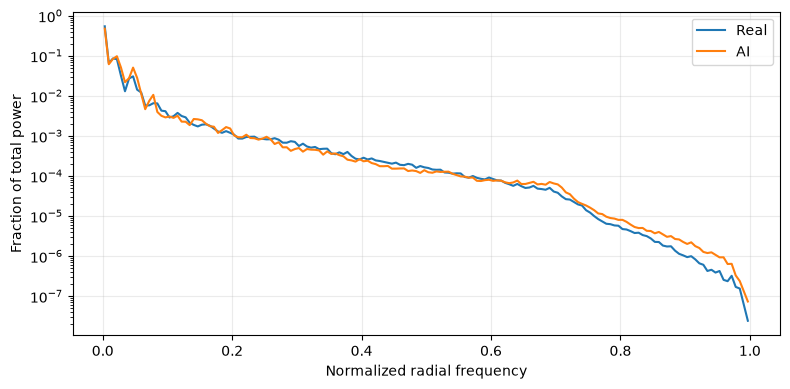

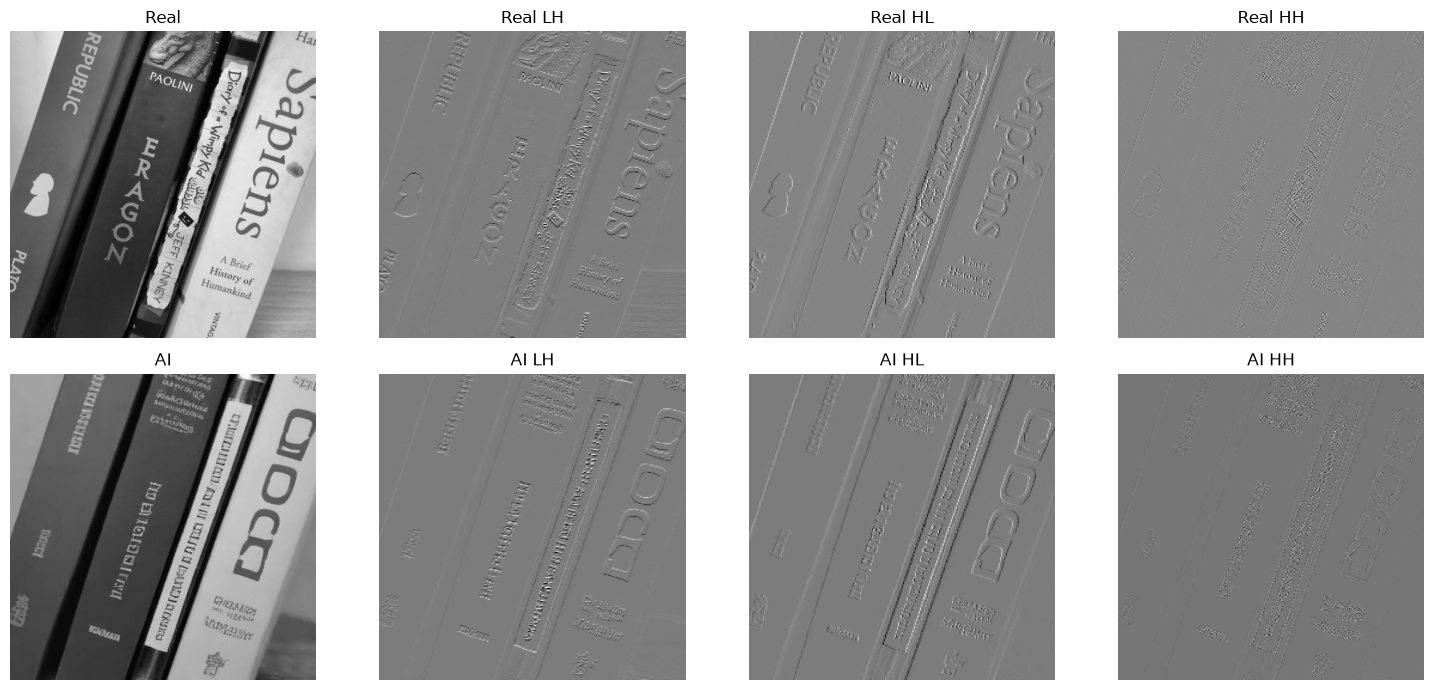

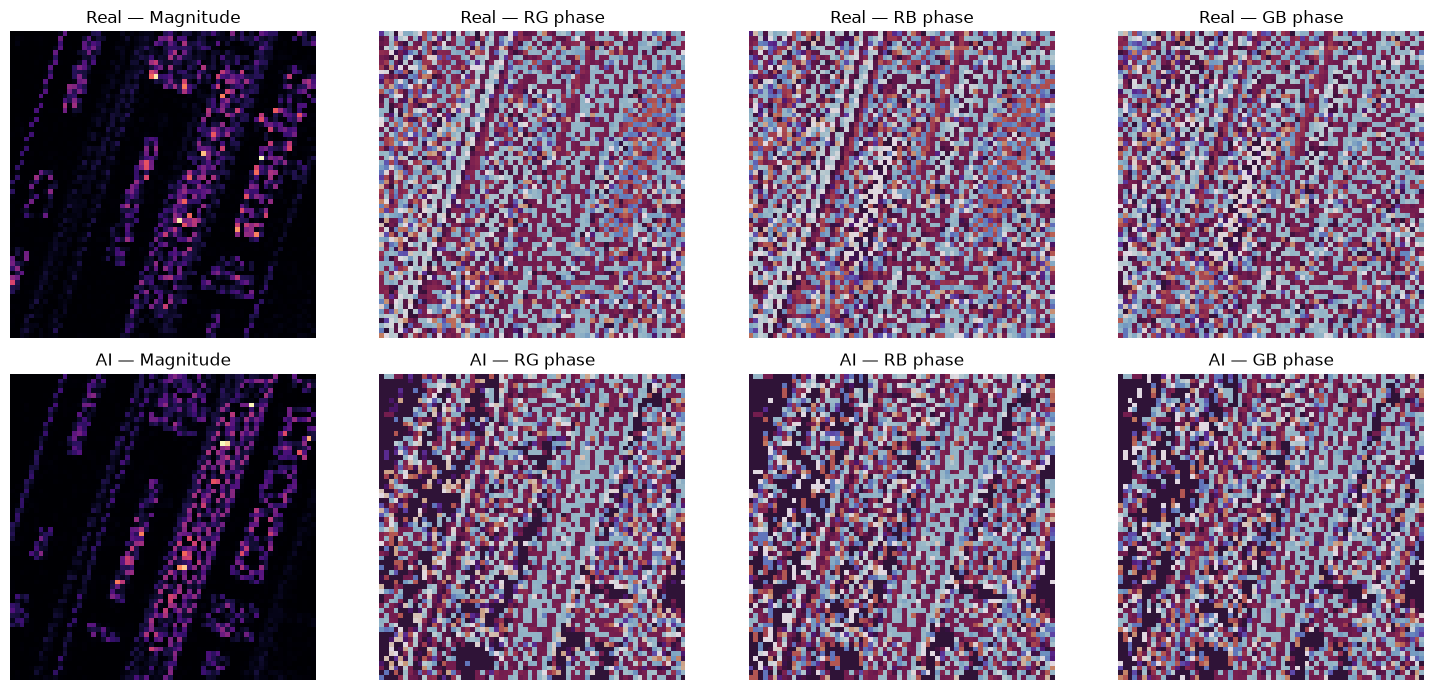

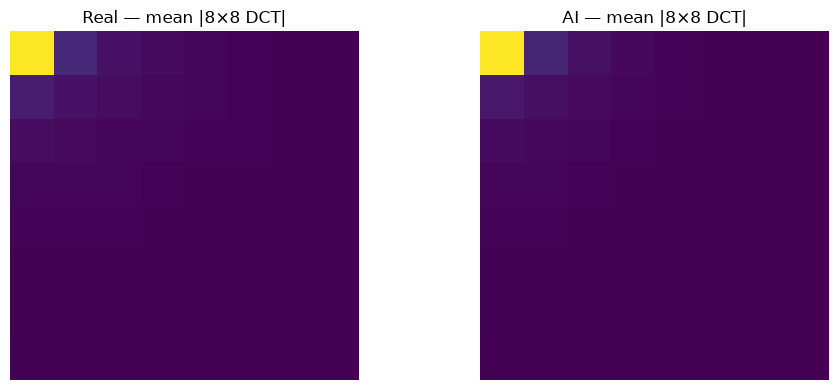

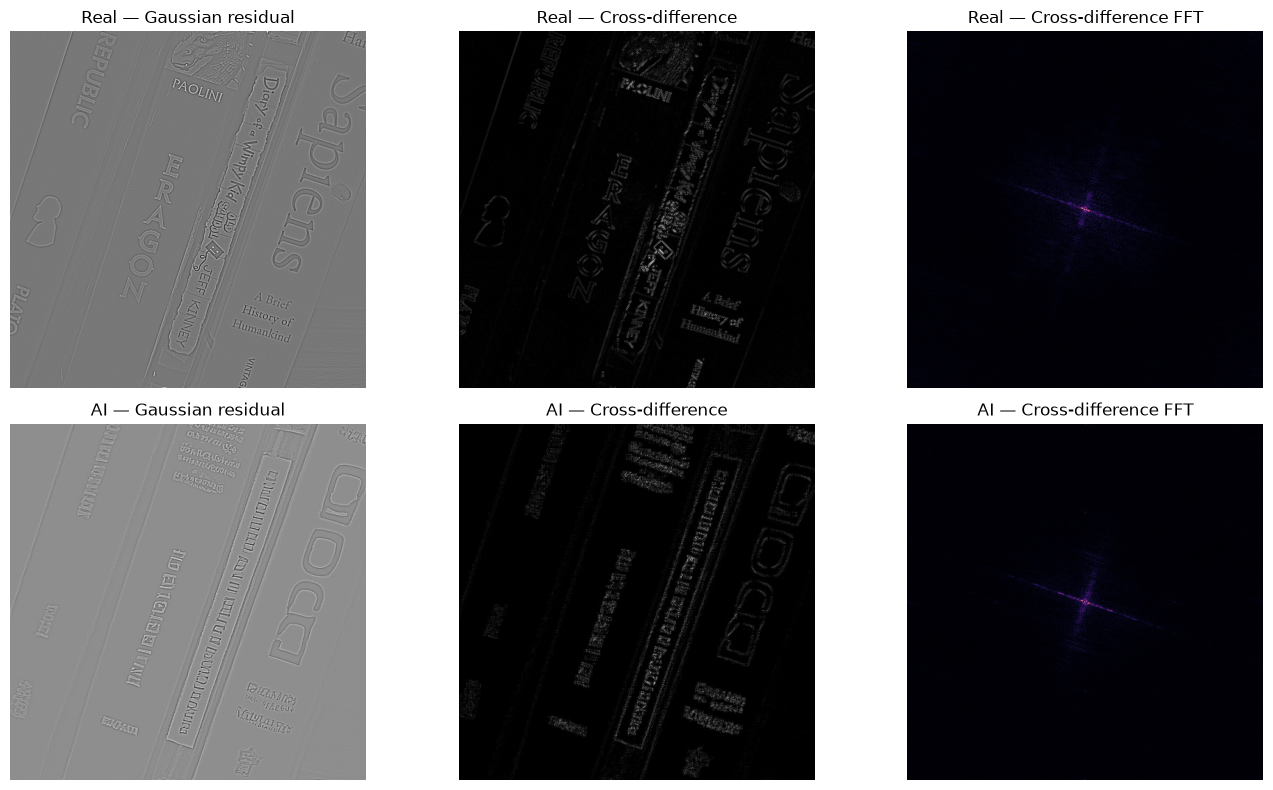

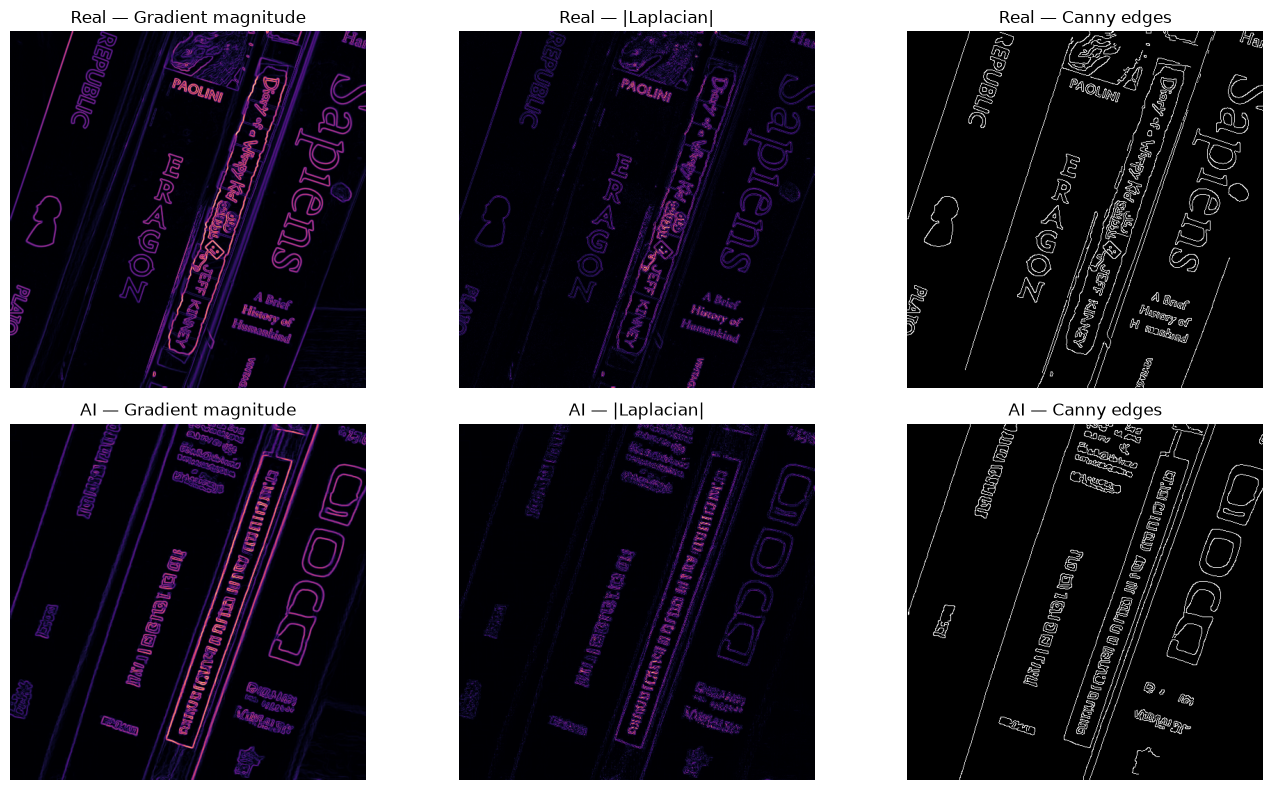

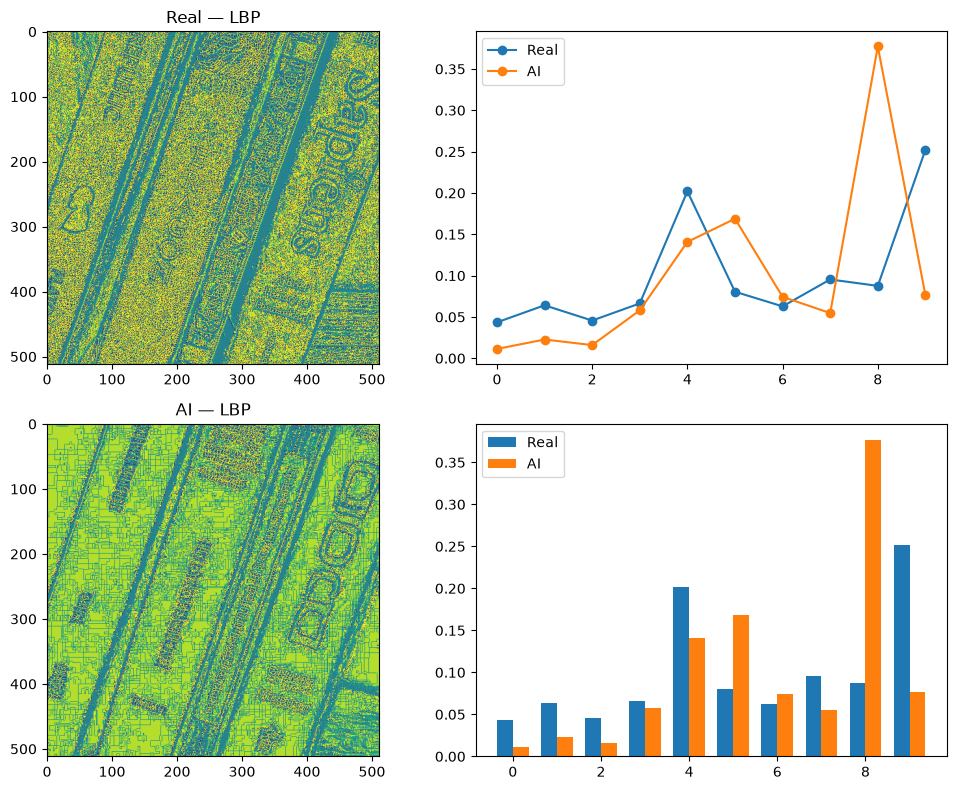

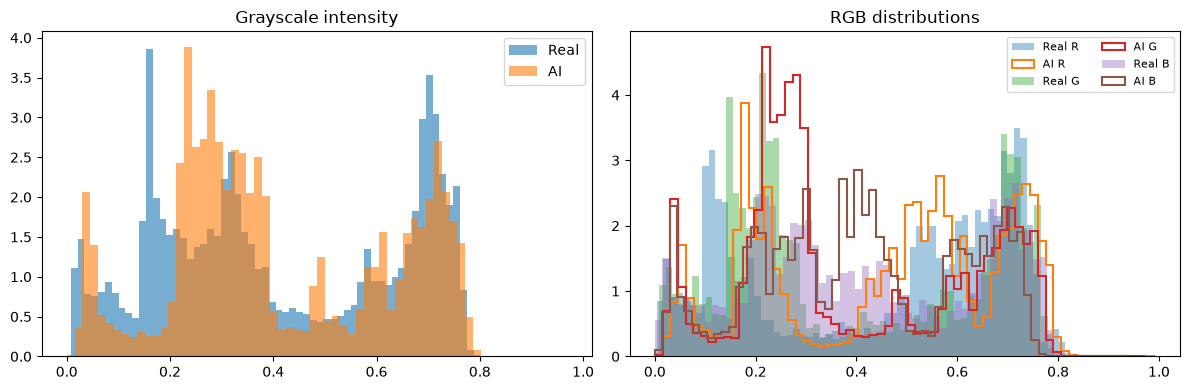

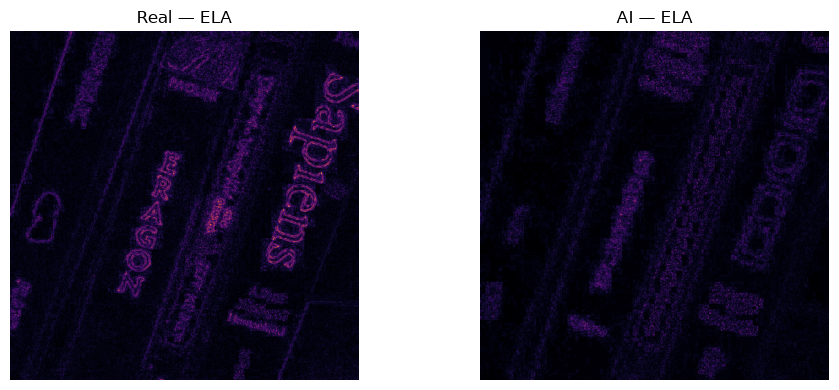

Finished 1/8: books
Finished 2/8: city
Finished 3/8: fabric
Finished 4/8: forest
Finished 5/8: fur
Finished 6/8: notes
Finished 7/8: p1
Finished 8/8: p2


,pair,real__low_freq_ratio,real__mid_freq_ratio,real__high_freq_ratio,real__spectral_centroid,real__LL3_energy,real__LL3_entropy,real__LH3_energy,real__LH3_absmean,real__LH3_entropy,...,ai__rgb_corr_rg,ai__rgb_corr_rb,ai__rgb_corr_gb,ai__hsv_saturation_mean,ai__hsv_value_mean,ai__hsv_saturation_std,ai__ela_mean,ai__ela_std,ai__ela_p95,ai__ela_max
0,books,0.973129,0.023810,0.003061,0.027456,13.948885,7.793007,0.052564,0.113457,5.273705,...,0.863481,0.708738,0.932417,0.328741,0.506460,0.218566,0.005069,0.005354,0.015686,0.067974
1,city,0.967974,0.027120,0.004906,0.023218,19.796944,6.906032,0.041739,0.093069,4.462185,...,0.993654,0.980011,0.994270,0.142093,0.596035,0.073127,0.004148,0.004463,0.013072,0.104575
2,fabric,0.856589,0.075240,0.068171,0.094356,13.158087,7.287775,0.005627,0.054589,6.514124,...,0.888347,0.610351,0.904002,0.253172,0.541513,0.067253,0.006260,0.005599,0.016993,0.058824
3,forest,0.971261,0.021959,0.006781,0.021035,13.349055,7.015172,0.051958,0.110968,4.927612,...,0.997307,0.988058,0.995329,0.192788,0.326765,0.137675,0.004264,0.005186,0.014379,0.074510
4,fur,0.649688,0.305241,0.045071,0.182217,22.852585,7.140827,0.049299,0.164657,6.835931,...,0.998788,0.997902,0.998700,0.076569,0.580226,0.024210,0.009569,0.007373,0.023529,0.067974


In [15]:
# -----------------------------
# Extract all features
# -----------------------------

def extract_image_features(rgb, gray, path):
    fft = fft_features(gray)
    dwt, _ = dwt_features(gray)
    qwt, _ = quaternion_wavelet_features(rgb)
    dct = block_dct_features(gray)
    residual = residual_features(rgb, gray)
    edges = edge_contour_features(gray)
    lbp = lbp_features(gray)
    glcm, _ = glcm_features(gray)
    color = intensity_color_features(rgb, gray)
    ela = ela_features_from_path(path)

    features = {}
    for group in [fft, dwt, qwt, dct, residual, edges, lbp, glcm, color, ela]:
        features.update(scalar_only(group))

    return features, {
        "fft": fft,
        "dwt": dwt,
        "qwt": qwt,
        "dct": dct,
        "residual": residual,
        "edges": edges,
        "lbp": lbp,
        "glcm": glcm,
        "color": color,
        "ela": ela,
    }

all_rows = []
cache = {}

with torch.inference_mode():
    for index, (stem, real_path, ai_path) in enumerate(pairs, start=1):
        real_rgb, ai_rgb, real_gray, ai_gray = load_pair_tensors(
            real_path,
            ai_path,
        )

        real_features, real_maps = extract_image_features(
            real_rgb,
            real_gray,
            real_path,
        )
        ai_features, ai_maps = extract_image_features(
            ai_rgb,
            ai_gray,
            ai_path,
        )

        cache[stem] = {
            "real_rgb": real_rgb,
            "ai_rgb": ai_rgb,
            "real_gray": real_gray,
            "ai_gray": ai_gray,
            "real": real_maps,
            "ai": ai_maps,
        }

        row = {"pair": stem}
        row.update({f"real__{k}": v for k, v in real_features.items()})
        row.update({f"ai__{k}": v for k, v in ai_features.items()})
        all_rows.append(row)

        show = SHOW_ALL_VISUALS or index == 1

        plot_fft_pair(stem, real_gray, ai_gray, show)
        plot_dwt_pair(stem, real_gray, ai_gray, show)
        plot_qwt_pair(stem, real_rgb, ai_rgb, show)
        plot_dct_pair(stem, real_gray, ai_gray, show)
        plot_residual_pair(stem, real_rgb, ai_rgb, real_gray, ai_gray, show)
        plot_edges_pair(stem, real_gray, ai_gray, show)
        plot_lbp_pair(stem, real_gray, ai_gray, show)
        plot_intensity_pair(stem, real_rgb, ai_rgb, real_gray, ai_gray, show)
        plot_ela_pair(
            stem,
            real_maps["ela"],
            ai_maps["ela"],
            show,
        )

        print(f"Finished {index}/{len(pairs)}: {stem}")

raw_df = pd.DataFrame(all_rows)
raw_df.to_csv(
    OUT_DIR / "all_scalar_features.csv",
    index=False,
)

raw_df.head()

In [16]:
# -----------------------------
# Paired differences
# -----------------------------

feature_names = sorted({
    column.split("__", 1)[1]
    for column in raw_df.columns
    if column.startswith("real__") or column.startswith("ai__")
})

feature_names = [
    feature
    for feature in feature_names
    if f"real__{feature}" in raw_df.columns
    and f"ai__{feature}" in raw_df.columns
]

delta_rows = []

for _, row in raw_df.iterrows():
    result = {"pair": row["pair"]}

    for feature in feature_names:
        real_value = float(row[f"real__{feature}"])
        ai_value = float(row[f"ai__{feature}"])

        result[f"{feature}__real"] = real_value
        result[f"{feature}__ai"] = ai_value
        result[f"{feature}__delta"] = ai_value - real_value
        result[f"{feature}__relative_delta"] = (
            (ai_value - real_value) / (abs(real_value) + 1e-12)
        )

    delta_rows.append(result)

delta_df = pd.DataFrame(delta_rows)
delta_df.to_csv(
    OUT_DIR / "paired_feature_differences.csv",
    index=False,
)

delta_df.head()

,pair,HH1_absmean__real,HH1_absmean__ai,HH1_absmean__delta,HH1_absmean__relative_delta,HH1_energy__real,HH1_energy__ai,HH1_energy__delta,HH1_energy__relative_delta,HH1_entropy__real,...,synth_r_p8_d_mean__delta,synth_r_p8_d_mean__relative_delta,synth_r_p8_x_mean__real,synth_r_p8_x_mean__ai,synth_r_p8_x_mean__delta,synth_r_p8_x_mean__relative_delta,synth_r_p8_y_mean__real,synth_r_p8_y_mean__ai,synth_r_p8_y_mean__delta,synth_r_p8_y_mean__relative_delta
0,books,0.006714,0.003971,-0.002743,-0.408601,0.000271,0.000162,-0.000109,-0.401305,3.697219,...,0.006960,0.252184,0.045106,0.021723,-0.023383,-0.518406,0.042019,0.068454,0.026434,0.629104
1,city,0.006613,0.002147,-0.004466,-0.675328,0.000192,0.000067,-0.000125,-0.649641,3.985353,...,-0.019502,-0.492964,0.052828,0.027616,-0.025212,-0.477250,0.024632,0.075907,0.051275,2.081606
2,fabric,0.019231,0.005875,-0.013357,-0.694525,0.000872,0.000130,-0.000742,-0.850975,5.946820,...,0.003645,0.154596,0.065044,0.071181,0.006137,0.094357,0.072449,0.009129,-0.063320,-0.873993
3,forest,0.012506,0.004798,-0.007709,-0.616385,0.001025,0.000333,-0.000692,-0.675553,3.816390,...,0.018043,0.613159,0.084423,0.030357,-0.054066,-0.640414,0.031351,0.034732,0.003380,0.107825
4,fur,0.018567,0.019881,0.001314,0.070788,0.000679,0.000759,0.000080,0.118264,6.159128,...,0.036166,1.215682,0.070134,0.255785,0.185651,2.647107,0.091752,0.161883,0.070131,0.764360


In [17]:
# -----------------------------
# Paired statistics
# -----------------------------

def exact_signflip_pvalue(differences):
    differences = np.asarray(differences, dtype=float)
    differences = differences[np.isfinite(differences)]
    n = len(differences)

    if n == 0:
        return np.nan

    if n > 20:
        raise ValueError(
            "Exact sign-flip enumeration is intended for small n. "
            "Use Monte Carlo for n > 20."
        )

    observed = abs(differences.mean())

    signs = np.array(
        list(itertools.product([-1, 1], repeat=n)),
        dtype=float,
    )

    simulated_means = (
        signs * differences[None, :]
    ).mean(axis=1)

    return float(
        (np.abs(simulated_means) >= observed - 1e-15).mean()
    )

def cohens_dz(differences):
    differences = np.asarray(differences, dtype=float)
    differences = differences[np.isfinite(differences)]

    if len(differences) < 2:
        return np.nan

    standard_deviation = np.std(differences, ddof=1)

    if standard_deviation == 0:
        return np.nan

    return float(
        differences.mean() / standard_deviation
    )

def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    adjusted = np.full_like(p_values, np.nan)

    valid = np.isfinite(p_values)
    p = p_values[valid]

    if len(p) == 0:
        return adjusted

    order = np.argsort(p)
    ranked = p[order]
    m = len(ranked)

    correction = (
        ranked * m / np.arange(1, m + 1)
    )

    monotone = np.minimum.accumulate(
        correction[::-1]
    )[::-1]

    restored = np.empty(m)
    restored[order] = np.minimum(monotone, 1.0)

    adjusted[valid] = restored
    return adjusted

stats_rows = []

for feature in feature_names:
    differences = delta_df[
        f"{feature}__delta"
    ].to_numpy(float)

    differences = differences[np.isfinite(differences)]

    if len(differences):
        stats_rows.append({
            "feature": feature,
            "n_pairs": len(differences),
            "mean_delta_ai_minus_real": float(differences.mean()),
            "median_delta": float(np.median(differences)),
            "std_delta": (
                float(np.std(differences, ddof=1))
                if len(differences) > 1
                else np.nan
            ),
            "cohens_dz": cohens_dz(differences),
            "direction_consistency_ai_gt_real": float(
                np.mean(differences > 0)
            ),
            "exact_signflip_p": exact_signflip_pvalue(differences),
        })

stats_df = pd.DataFrame(stats_rows)

stats_df["q_fdr"] = benjamini_hochberg(
    stats_df["exact_signflip_p"].to_numpy()
)

stats_df = stats_df.sort_values(
    ["q_fdr", "exact_signflip_p"]
)

stats_df.to_csv(
    OUT_DIR / "paired_statistics.csv",
    index=False,
)

stats_df.head(30)

,feature,n_pairs,mean_delta_ai_minus_real,median_delta,std_delta,cohens_dz,direction_consistency_ai_gt_real,exact_signflip_p,q_fdr
3,HH2_absmean,8,-0.010312,-0.009552,0.005951,-1.732656,0.0,0.007812,0.02532
5,HH2_entropy,8,-1.313646,-1.368271,0.571258,-2.299565,0.0,0.007812,0.02532
6,HH3_absmean,8,-0.013771,-0.011223,0.009444,-1.458210,0.0,0.007812,0.02532
9,HL1_absmean,8,-0.009138,-0.006483,0.009668,-0.945181,0.0,0.007812,0.02532
11,HL1_entropy,8,-1.135556,-1.082980,0.603879,-1.880435,0.0,0.007812,0.02532
12,HL2_absmean,8,-0.015867,-0.013189,0.012927,-1.227437,0.0,0.007812,0.02532
14,HL2_entropy,8,-0.897274,-0.897933,0.389683,-2.302574,0.0,0.007812,0.02532
18,LH1_absmean,8,-0.006025,-0.006432,0.003272,-1.841585,0.0,0.007812,0.02532
20,LH1_entropy,8,-1.199208,-1.238079,0.682560,-1.756928,0.0,0.007812,0.02532
21,LH2_absmean,8,-0.012141,-0.014048,0.007237,-1.677613,0.0,0.007812,0.02532


In [18]:
# -----------------------------
# Presentation plots
# -----------------------------

presentation_features = [
    "high_freq_ratio",
    "spectral_centroid",
    "detail_energy_ratio",
    "qwt_detail_magnitude_energy_ratio",
    "qwt_HH3_magnitude_mean",
    "qwt_HH3_magnitude_entropy",
    "qwt_HH3_phase_rg_circular_coherence",
    "qwt_HH3_phase_rb_circular_coherence",
    "qwt_HH3_phase_gb_circular_coherence",
    "qwt_HH3_quaternion_skewness",
    "qwt_HH3_quaternion_kurtosis",
    "dct_highfreq_ratio_mean",
    "dct_dc_ratio_mean",
    "hp_std",
    "crossdiff_std",
    "crossdiff_fft_highfreq_ratio",
    "synth_r_p2_x_mean",
    "synth_r_p4_x_mean",
    "synth_r_p8_x_mean",
    "gradient_mean",
    "laplacian_absmean",
    "edge_density",
    "lbp_hist_entropy",
    "glcm_contrast_mean",
    "glcm_homogeneity_mean",
    "glcm_energy_mean",
    "intensity_entropy",
    "rgb_corr_rg",
    "rgb_corr_rb",
    "rgb_corr_gb",
    "ela_mean",
]

available = [
    feature
    for feature in presentation_features
    if feature in feature_names
]

for feature in available:
    real_values = delta_df[
        f"{feature}__real"
    ].to_numpy(float)

    ai_values = delta_df[
        f"{feature}__ai"
    ].to_numpy(float)

    fig, ax = plt.subplots(figsize=(7, 4))

    for real_value, ai_value in zip(real_values, ai_values):
        ax.plot(
            [0, 1],
            [real_value, ai_value],
            marker="o",
            alpha=0.65,
        )

    ax.set_xticks([0, 1], ["Real", "AI"])
    ax.set_title(f"Paired comparison — {feature}")
    ax.grid(alpha=0.25)

    plt.tight_layout()
    fig.savefig(
        OUT_DIR / f"paired_{feature}.png",
        dpi=160,
        bbox_inches="tight",
    )

    if SHOW_ALL_VISUALS:
        plt.show()

    plt.close(fig)

if available:
    heat = np.array([
        np.clip(
            delta_df[
                f"{feature}__relative_delta"
            ].to_numpy(float),
            -2,
            2,
        )
        for feature in available
    ])

    fig, ax = plt.subplots(
        figsize=(12, max(5, 0.35 * len(available)))
    )

    image = ax.imshow(
        heat,
        aspect="auto",
        cmap="coolwarm",
        vmin=-2,
        vmax=2,
    )

    ax.set_yticks(np.arange(len(available)), available)
    ax.set_xticks(
        np.arange(len(delta_df)),
        delta_df["pair"],
        rotation=45,
        ha="right",
    )
    ax.set_title(
        "AI vs Real relative feature change "
        "(clipped to ±200%)"
    )

    fig.colorbar(
        image,
        ax=ax,
        label="(AI − Real) / |Real|",
    )

    plt.tight_layout()
    fig.savefig(
        OUT_DIR / "paired_relative_change_heatmap.png",
        dpi=180,
        bbox_inches="tight",
    )

    if SHOW_ALL_VISUALS:
        plt.show()

    plt.close(fig)

In [19]:
# -----------------------------
# Final feature report
# -----------------------------

report_columns = [
    "feature",
    "mean_delta_ai_minus_real",
    "median_delta",
    "cohens_dz",
    "direction_consistency_ai_gt_real",
    "exact_signflip_p",
    "q_fdr",
]

report = stats_df[report_columns].copy()
report["abs_effect"] = report["cohens_dz"].abs()
report = report.sort_values(
    "abs_effect",
    ascending=False,
)

report.to_csv(
    OUT_DIR / "final_feature_report.csv",
    index=False,
)

report.head(30)

,feature,mean_delta_ai_minus_real,median_delta,cohens_dz,direction_consistency_ai_gt_real,exact_signflip_p,q_fdr,abs_effect
136,qwt_HL2_magnitude_entropy,-0.868330,-0.879178,-3.063366,0.0,0.007812,0.02532,3.063366
172,qwt_LH2_magnitude_entropy,-0.748655,-0.669618,-2.454539,0.0,0.007812,0.02532,2.454539
23,LH2_entropy,-0.961482,-0.971140,-2.363594,0.0,0.007812,0.02532,2.363594
14,HL2_entropy,-0.897274,-0.897933,-2.302574,0.0,0.007812,0.02532,2.302574
5,HH2_entropy,-1.313646,-1.368271,-2.299565,0.0,0.007812,0.02532,2.299565
83,lbp_mean_code,0.474090,0.481371,2.256247,1.0,0.007812,0.02532,2.256247
91,qwt_HH1_phase_gb_circular_coherence,0.443342,0.503045,2.115547,1.0,0.007812,0.02532,2.115547
93,qwt_HH1_phase_rb_circular_coherence,0.447285,0.515161,2.107296,1.0,0.007812,0.02532,2.107296
95,qwt_HH1_phase_rg_circular_coherence,0.440841,0.503032,2.096064,1.0,0.007812,0.02532,2.096064
127,qwt_HL1_phase_gb_circular_coherence,0.422071,0.502217,2.071056,1.0,0.007812,0.02532,2.071056


## Final interpretation reminder

This remains an exploratory comparison of the available real/AI pairs.

The refined notebook changes the implementation and processing stack. Therefore, the previous notebook's numerical results should **not** be copied into the new report without rerunning this notebook on the dataset.

The important methodological rule is to compare each real photograph with its corresponding AI image, then interpret feature differences together rather than treating one feature as a universal AI signature.

### Important v3 interpretation note

A statistically strong `qwt_*` feature on these eight matched pairs does **not** establish a general AI detector. The QWT/CQWT literature motivating this section used much larger datasets and different real-vs-CG tasks. Our v3 result is a hypothesis-generating experiment. citeturn3search0turn3search5
